start_time                                   2025-09-27 01:21:19
end_time                                     2025-09-27 01:22:37
Bx                                                      -1.93618
By                                                     -4.495037
Bz                                                      0.769296
score                                                   0.663395
file_name      TracersDispersionEvent_TS2_2025-09-27T01:21:19...
B                                                       4.954389
cone_angle                                             113.00435
clock_angle                                           279.711705
label                                                 ByDominant
aci_file       data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250927_...
ead_file       data/Sept30_Storm/ead/ts2_def_ead_20250927_v0....
Name: 0, dtype: object
d = 15.79
Bs at satellite 44699.46130975912 nT


/home/ubuntu/tracers-work/tracers-first-results-paper/lib_eventvis.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(new_xticklabels)


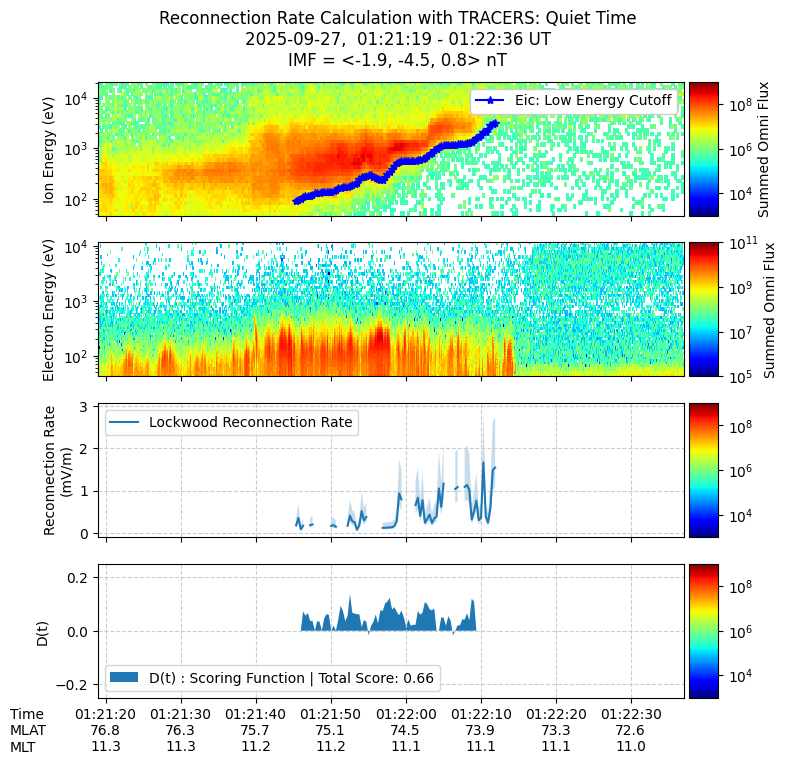

In [1]:
import lib_eventvis
import pandas as pd
from datetime import timedelta

df = pd.read_csv('output/Sept30_Storm_filtered.csv', parse_dates=['start_time', 'end_time'], index_col=0)

print(df.iloc[0])

def get_d(i):
    with open(f'output/Sept30_Storm/dprime_{i}.txt', 'r') as fh:
        d = float(fh.read())
        print(f'd = {d:.2f}')
        return d

fig = lib_eventvis.make_event_vis(
    row=df.iloc[0],
    ace_file='data/Sept30_Storm/ace/ts2_l2_ace_def_20250927_v1.1.0.cdf',
    scoring_file='output/Sept30_Storm/data/TracersDispersionEvent_TS2_2025-09-27T01:21:19_2025-09-27T01:22:37_SCORE.csv',
    d=get_d(0),
    dispersion_stime=df.iloc[0].start_time,
    dispersion_etime=df.iloc[0].end_time-timedelta(seconds=25),
    title_label='Quiet Time',
    ascending=True,
)
fig.savefig('plots/recon_rate_event.png', dpi=300, bbox_inches='tight')